# Jerarquia de sensores.

Para esto, use un sistema IoT de monitoreo para prevención de incendios eléctricos
residenciales que trabaje el semestre pasado. La relación "es-un" es real: cada sensor concreto ES un
Sensor (comparte la misma interfaz de lectura y reporte), pero cada uno
interpreta su magnitud física de forma distinta

A continuación, describiré los atributos y los metodos:

@startuml
  class Sensor {
    +id_sensor
    +ubicacion
    +historial
    +unidad
    +leer(valor_crudo)
    +promedio_historial()
    +interpretar(valor)
    +reportar(valor_crudo)
  }
  class SensorTemperatura {
    +umbral_riesgo
    +interpretar(valor)
  }
  class SensorHumedad {
    +interpretar(valor)
  }
  class SensorCorriente {
    +corriente_nominal
    +interpretar(valor)
    +reportar(valor_crudo)
  }
  Sensor <|-- SensorTemperatura
  Sensor <|-- SensorHumedad
  Sensor <|-- SensorCorriente
  @enduml

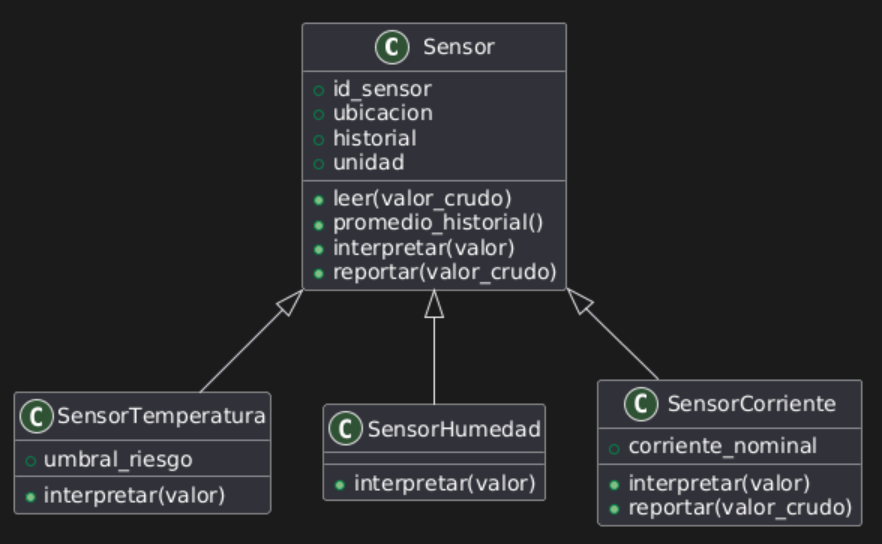

In [ ]:
from datetime import datetime


class Sensor:
    """Superclase: comportamiento común a TODO sensor del sistema."""

    def __init__(self, id_sensor: str, ubicacion: str):
        self.id_sensor = id_sensor
        self.ubicacion = ubicacion
        self.historial = []  # lista de lecturas (valor, timestamp)
        self.unidad = "u."   # las subclases la sobrescriben

    def leer(self, valor_crudo: float) -> float:
        self.historial.append((valor_crudo, datetime.now()))
        return valor_crudo

    def promedio_historial(self) -> float:
        if not self.historial:
            return 0.0
        return sum(v for v, _ in self.historial) / len(self.historial)

    def interpretar(self, valor: float) -> str:
        return f"Valor genérico registrado: {valor} {self.unidad}"

    def reportar(self, valor_crudo: float) -> str:
        valor = self.leer(valor_crudo)
        estado = self.interpretar(valor)
        return f"[{self.id_sensor} @ {self.ubicacion}] {estado}"


class SensorTemperatura(Sensor):

    def __init__(self, id_sensor: str, ubicacion: str, umbral_riesgo: float = 60.0):
        super().__init__(id_sensor, ubicacion)  # reutiliza init del padre
        self.unidad = "°C"
        self.umbral_riesgo = umbral_riesgo

    def interpretar(self, valor: float) -> str:  # único método distinto
        if valor >= self.umbral_riesgo:
            return f"¡RIESGO! {valor} {self.unidad} supera el umbral ({self.umbral_riesgo} {self.unidad})"
        return f"Temperatura normal: {valor} {self.unidad}"


class SensorHumedad(Sensor):

    def __init__(self, id_sensor: str, ubicacion: str):
        super().__init__(id_sensor, ubicacion)
        self.unidad = "%HR"

    def interpretar(self, valor: float) -> str:
        if valor < 20:
            return f"Ambiente muy seco: {valor} {self.unidad} (mayor riesgo de chispa/arco)"
        return f"Humedad normal: {valor} {self.unidad}"


class SensorCorriente(Sensor):

    def __init__(self, id_sensor: str, ubicacion: str, corriente_nominal: float):
        super().__init__(id_sensor, ubicacion)
        self.unidad = "A"
        self.corriente_nominal = corriente_nominal

    def interpretar(self, valor: float) -> str:
        sobrecarga = valor / self.corriente_nominal
        if sobrecarga > 1.2:
            return f"SOBRECARGA: {valor} {self.unidad} ({sobrecarga:.0%} de la nominal)"
        return f"Corriente estable: {valor} {self.unidad}"

    def reportar(self, valor_crudo: float) -> str:
        base = super().reportar(valor_crudo)
        carga = (self.promedio_historial() / self.corriente_nominal) * 100
        return f"{base} | Carga promedio histórica: {carga:.1f}%"


if __name__ == "__main__":
    sensores = [
        SensorTemperatura("T-01", "Tablero eléctrico cocina", umbral_riesgo=55),
        SensorHumedad("H-01", "Cuarto de medidores"),
        SensorCorriente("C-01", "Circuito habitaciones", corriente_nominal=15),
    ]

    lecturas = [58.3, 15.0, 19.2]

    for sensor, lectura in zip(sensores, lecturas):
        print(sensor.reportar(lectura))

[T-01 @ Tablero eléctrico cocina] ¡RIESGO! 58.3 °C supera el umbral (55 °C)
[H-01 @ Cuarto de medidores] Ambiente muy seco: 15.0 %HR (mayor riesgo de chispa/arco)
[C-01 @ Circuito habitaciones] SOBRECARGA: 19.2 A (128% de la nominal) | Carga promedio histórica: 128.0%
